# 🎧 Calming Whisper's "Crazy Heads"
### Reproducing a result from the *Calm-Whisper* paper (arXiv:2505.12969)

OpenAI's **Whisper** is one of the best speech-to-text models in the world. But it has a
strange failure: feed it audio with **no speech at all** (a dog barking, a drill, traffic)
and it will often confidently **invent** words. This is called **hallucination**.

The paper you were given (`2505.12969v1.pdf`) makes a remarkable claim: a few specific
**attention heads** inside Whisper's decoder are responsible for most of this hallucination.
**Switch those heads off** and hallucination drops a lot — *without* hurting normal
transcription.

In this notebook you will:
1. Understand **why** transformers have many attention heads, and what **masking** one means.
2. Measure Whisper's **baseline** hallucination rate (on non-speech) and accuracy (WER, on speech).
3. **Mask attention heads** yourself and try to reproduce — or improve on — the paper's result.

> 📄 Keep the paper open. You'll be asked to look up definitions in it.


## 1 · Attention, and why there are *many* heads

A transformer understands a sequence by letting each position **attend** to others — it asks
*"which other tokens should I look at to make sense of this one?"*

A single attention can only track **one kind of relationship** at a time. So transformers run
**several attention "heads" in parallel**, each on its own slice of the representation.
Different heads specialize:

- one head may link a **verb to its subject**,
- another connects a **pronoun to the noun** it refers to,
- another simply tracks **word order / position**,
- …and some heads, it turns out, learn **unhelpful or even harmful** habits.

Whisper-large-v3's decoder has **32 layers**, each with **20 heads**. That's a lot of little
specialists — and this assignment is about finding the ones that misbehave.


## 2 · Two kinds of attention in the Whisper *decoder*

Whisper is an **encoder–decoder** model: the **encoder** turns audio into features, the
**decoder** writes the text. Every decoder layer has **two** attention blocks:

| Attention block | What it looks at | Intuition |
|---|---|---|
| **Self-attention** (`self_attn`) | the text generated so far | keeps the sentence grammatical & coherent |
| **Cross-attention** (`encoder_attn`) | the **audio** features from the encoder | this is how the text "listens" to the sound |

🤔 **Think before you code:** if Whisper invents words for audio containing *no speech*, which
block is the more likely culprit — the one that reads the **text**, or the one that reads the
**audio**? Write down your guess; you'll test it later.

The one that reads the audio



## 3 · What does "masking a head" mean?

**Masking a head = switching it off.** We force that one head's output to **zero**, let the
rest of the model run normally, and observe what changes.

This is a classic scientific move: to learn what a part does, **disable it and measure the
effect** — like studying a brain region by watching what changes when it goes quiet. If
switching off head #k makes hallucinations vanish, head #k was helping cause them.

> ⚠️ **Heads-up:** the most "obvious" way to mask a head in the `transformers` library
> (the `decoder_head_mask` argument) **silently does nothing** in recent versions. Getting
> masking to actually work is part of the challenge. If you're stuck, a working example lives
> in **`hints.md`** — but try first!


## Setup
Run the next cells to load the model, the data, and the metric tools.

In [1]:
# --- Setup: load Whisper-large-v3 ---

import torch, numpy as np, librosa, warnings
warnings.filterwarnings("ignore")
from transformers import WhisperForConditionalGeneration, WhisperProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "openai/whisper-large-v3"

model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME, dtype=torch.float16).to(DEVICE).eval()
processor = WhisperProcessor.from_pretrained(MODEL_NAME)

print("Loaded", MODEL_NAME, "on", DEVICE)
print("Decoder:", model.config.decoder_layers, "layers,",
      model.config.decoder_attention_heads, "heads per layer")


Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

Loaded openai/whisper-large-v3 on cuda
Decoder: 32 layers, 20 heads per layer


## 4 · Metric 1 — Hallucination rate (non-speech audio)

**UrbanSound8K** = 8,732 clips of environmental sounds (dog barks, drills, sirens, AC units).
**None contain speech.** A trustworthy model should output **nothing** (an empty string).
If it outputs *any* text, that clip counts as a **hallucination**.

$$\text{Hallucination rate}=\frac{\#\{\text{clips that produced any text}\}}{\#\{\text{all clips}\}}$$

📄 **Look it up:** open the paper at **Section 2.2, Equation (1)** and read the authors' exact
definition. Notice it's a simple **yes/no per clip**: did text come out, or not?


## 5 · Metric 2 — Word Error Rate (real speech)

Turning off heads might cut hallucinations — but does it **break normal transcription**?
To check, we measure **Word Error Rate (WER)** on real speech (**LibriSpeech**):

$$\text{WER}=\frac{S+D+I}{N}=\frac{\text{substitutions}+\text{deletions}+\text{insertions}}{\text{words in the reference}}$$

Lower is better (0 = perfect). We test on **test-clean** (easy) and **test-other** (harder, noisier).

🎯 **The whole point of the paper:** a good fix should **lower hallucination** while keeping
**WER almost unchanged**. Both numbers matter.


### Load datasets & metric tools

In [2]:
# --- Load the datasets ---
from datasets import load_dataset

# Non-speech audio (for hallucination). ~8,700 clips.
urban = load_dataset("mteb/urbansound8K", split="train")

# Real speech (for WER). Each config's test split is named "test".
# NOTE: 'other' downloads on first run (~300 MB).
libri_clean = load_dataset("openslr/librispeech_asr", "clean", split="test")
libri_other = load_dataset("openslr/librispeech_asr", "other", split="test")

print(len(urban), "non-speech clips |",
      len(libri_clean), "clean +", len(libri_other), "other speech utterances")

def audio16k(sample):
    a = sample["audio"]; arr = np.asarray(a["array"])
    if a["sampling_rate"] != 16000:
        arr = librosa.resample(arr, orig_sr=a["sampling_rate"], target_sr=16000)
    return arr

# A small, class-balanced sample of non-speech clips (keeps runtime short).
SAMPLE_PER_CLASS = 15                 # raise for more reliable numbers (slower)
_classes = [str(c) for c in urban["class"]]
URBAN_IDX = []
for c in sorted(set(_classes)):
    URBAN_IDX += [i for i, x in enumerate(_classes) if x == c][:SAMPLE_PER_CLASS]
print("Using", len(URBAN_IDX), "non-speech clips for the hallucination metric")


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

8732 non-speech clips | 2620 clean + 2939 other speech utterances
Using 150 non-speech clips for the hallucination metric


In [3]:
# --- Given tools: inference + metrics (you don't need to change these) ---
from tqdm.auto import tqdm

@torch.no_grad()
def transcribe_greedy(model, audio, max_steps=20):
    '''Decode greedily starting ONLY from <|startoftranscript|>.
    This lets Whisper choose to stay silent (emit no text) on non-speech — which is
    exactly what we want to detect hallucinations.'''
    feats = processor(audio, sampling_rate=16000, return_tensors="pt").input_features.to(DEVICE, model.dtype)
    enc = model.model.encoder(feats)                       # encode the audio ONCE
    ids = torch.tensor([[model.config.decoder_start_token_id]], device=DEVICE)
    toks = []
    for _ in range(max_steps):                             # then decode step by step
        logits = model(encoder_outputs=enc, decoder_input_ids=ids).logits
        nxt = logits[0, -1].argmax()
        if nxt.item() == model.config.eos_token_id:
            break
        toks.append(nxt.item())
        ids = torch.cat([ids, nxt.view(1, 1)], dim=1)
    return processor.tokenizer.decode(toks, skip_special_tokens=True).strip()

@torch.no_grad()
def transcribe_full(model, audio):
    '''Full, normal transcription (model.generate) — used for WER on real speech.'''
    feats = processor(audio, sampling_rate=16000, return_tensors="pt").input_features.to(DEVICE, model.dtype)
    ids = model.generate(feats)
    return processor.batch_decode(ids, skip_special_tokens=True)[0].strip()

def hallucination_rate(model, indices, show=0):
    '''Fraction of non-speech clips that produced ANY text.'''
    n_hall = 0
    for k, i in enumerate(tqdm(indices, desc="UrbanSound8K", leave=False)):
        text = transcribe_greedy(model, audio16k(urban[i]))
        n_hall += int(len(text) > 0)
        if k < show:
            print(f"   {str(urban[i]['class']):16s} -> {text!r}")
    return n_hall / len(indices) * 100

def _edit(r, h):                                            # word-level edit distance
    d = list(range(len(h) + 1))
    for i in range(1, len(r) + 1):
        prev, d[0] = d[0], i
        for j in range(1, len(h) + 1):
            prev, d[j] = d[j], min(d[j] + 1, d[j - 1] + 1, prev + (r[i - 1] != h[j - 1]))
    return d[len(h)]

def corpus_wer(model, ds, n):
    '''WER (%) over the first n utterances, using Whisper's English text normalizer.'''
    norm = processor.tokenizer.normalize
    errs = words = 0
    for i in tqdm(range(n), desc="WER", leave=False):
        ref = norm(ds[i]["text"]).split()
        hyp = norm(transcribe_full(model, audio16k(ds[i]))).split()
        errs += _edit(ref, hyp); words += max(len(ref), 1)
    return errs / words * 100

print("Tools ready: transcribe_greedy, transcribe_full, hallucination_rate, corpus_wer")


Tools ready: transcribe_greedy, transcribe_full, hallucination_rate, corpus_wer


## Baseline
First, measure Whisper **before** any masking. Keep these numbers.

In [4]:
# --- Baseline: Whisper with NO masking ---

base_hall = hallucination_rate(model, URBAN_IDX, show=5)
print(f"\nBaseline hallucination rate: {base_hall:.1f}%")

WER_N = 40                                    # utterances per set (raise for reliability)
base_wer_clean = corpus_wer(model, libri_clean, WER_N)
base_wer_other = corpus_wer(model, libri_other, WER_N)
print(f"Baseline WER  test-clean={base_wer_clean:.2f}%   test-other={base_wer_other:.2f}%")


UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


   air_conditioner  -> ''
   air_conditioner  -> ''
   air_conditioner  -> 'The water is boiling.'
   air_conditioner  -> 'so'
   air_conditioner  -> 'The water is boiling.'

Baseline hallucination rate: 43.3%


WER:   0%|          | 0/40 [00:00<?, ?it/s]

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its para

WER:   0%|          | 0/40 [00:00<?, ?it/s]

Baseline WER  test-clean=2.04%   test-other=1.96%


## 6 · Task — switch off attention heads

This is the heart of the assignment, and **no code recipe is given on purpose.** The goal is to
understand the mechanism well enough to build it. (If you ask an AI assistant to "mask Whisper's
heads," the obvious attempts *fail* for the reasons listed at the end — so you'll have to actually
understand what's going on to get past them.)

Read the conceptual sections below, then implement two functions in the next cell:
`mask_heads(...)` to switch heads off, and `remove_masks(...)` to put them back.

### What one attention head actually is

Inside **every** attention block the computation always has the same shape:

1. Each position's vector (size `d_model = 1280`) is turned into **queries, keys, and values**.
2. These are split into **`n_head` independent heads** (Whisper's decoder has **20**). Each head
   lives in its own little subspace of size `head_dim = d_model / n_head = 64` and computes
   attention **on its own**, ignoring the other heads.
3. Each head outputs **64 numbers** per position. The 20 heads' outputs are then **glued back
   together** into one 1280-vector, **head by head**: head 0 is the first 64 numbers, head 1 the
   next 64, and so on.
4. A final **output projection** (a single linear layer) mixes that 1280-vector back into a
   1280-vector that leaves the block. **This projection blends all 20 heads together.**

The crucial consequence: a single head's contribution is **cleanly separable only at step 3** —
the glued vector *before* the output projection — where it is one contiguous block of 64 numbers.

### What "masking a head" means

To switch head *k* off, you force **its** 64-number block to **zero** at step 3, and let the rest
of the block run normally. The model then behaves as though that head contributed nothing.

### Where these blocks live

Each decoder layer has **two** attention blocks (recall Concept 2): one that reads the **text so
far** (self-attention) and one that reads the **audio** (cross-attention). Your `mask_heads` must
target whichever block the caller asks for, in **every** decoder layer at once. To find them,
**explore the model** — e.g. `print(model)` and walk through `model.modules()` / the decoder's
layers — and identify the two attention sub-modules and the output projection inside each.

### Why the obvious attempts fail (understand these *before* you code)

- **A built-in "head-mask" argument.** Some library versions let you pass a head-mask into the
  model. On the version installed here it is **silently ignored** — it changes nothing. So never
  assume your mask worked: **prove** it (see the sanity check below).
- **Zeroing the block's final output.** Tempting, but **too late** — after the output projection
  the 20 heads are already blended, so there's no clean per-head block left to zero. The
  intervention has to happen at **step 3**, before that projection. (You'll be asked to explain
  this in the reflection.)
- **Decoding that forces a transcript.** If you measure hallucination with a decoder that *forces*
  Whisper to produce text (and suppresses its "stay silent" option), every non-speech clip emits
  text no matter what — masking will look useless. Use the **provided** `transcribe_greedy`, which
  lets the model choose to output nothing.

### Prove your masking is real

Once implemented, a masked head must be able to change the output:

```python
clip = audio16k(urban[200])
print("no mask:", repr(transcribe_greedy(model, clip)))
# apply your mask, transcribe again, then undo it with remove_masks(...)
```

If the two transcriptions can differ, your masking works. Now go reproduce — or refute — the paper.


In [5]:
def mask_heads(model, heads, attn_type="self"):
    '''Switch OFF the given heads in EVERY decoder layer.
       attn_type: "self" = self-attention, "cross" = cross-attention.
       Returns hook handles -> pass them to remove_masks() to undo.'''
    block    = "self_attn" if attn_type == "self" else "encoder_attn"
    n_head   = model.config.decoder_attention_heads               # 20
    head_dim = model.model.decoder.layers[0].self_attn.head_dim   # 64

    def make_hook(heads):
        def pre_hook(module, args):
            x = args[0]                          # numbers entering the block: [batch, seq, 1280]
            b, s, d = x.shape
            x = x.view(b, s, n_head, head_dim).clone()   # un-glue 1280 into (20 heads, 64 each)
            for h in heads:                      # x[:, :, h, :] is now "head h's 64 numbers"
                x[:, :, h, :] = 0
            return (x.view(b, s, d),) + args[1:]
        return pre_hook

    handles = []
    for layer in model.model.decoder.layers:
        attn = getattr(layer, block)
        handles.append(attn.out_proj.register_forward_pre_hook(make_hook(heads)))
    return handles



def remove_masks(state):
    '''Undo whatever mask_heads() did, restoring the model to normal.'''
    # ###### YOUR CODE HERE ######
    for h in handles:
        h.remove()
    # ############################


### 6a · Verify the paper's headline claim

The paper reports that masking **self-attention** heads `[1, 6, 11]` drops the UrbanSound8K
hallucination rate from **99.97% → 24.10%**. Test it on your sample.


In [17]:
handles = mask_heads(model, [1, 6, 11], attn_type="self")
print("self[1,6,11]:", round(hallucination_rate(model, URBAN_IDX), 1), "%   baseline:", round(base_hall, 1), "%")
remove_masks(handles)


UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

self[1,6,11]: 40.7 %   baseline: 43.3 %


### 6b · Find the best mask (don't trust the paper blindly)

Systematically search for the mask that **minimizes** hallucination. Consider:
- both attention blocks (`"self"` vs `"cross"`),
- single heads vs. combinations,
- whether a "good" combo from the paper is actually additive (does adding heads help or hurt?).

Decide on your `BEST_HEADS` / `BEST_TYPE`, then measure both metrics for it.


In [19]:
for attn in ["self", "cross"]:
    for i in range(20):
        handles = mask_heads(model, [i], attn_type=attn)
        print(f"{attn}[{i:2d}]:", round(hallucination_rate(model, URBAN_IDX), 1))
        remove_masks(handles)

UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

self[ 0]: 42.7


UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

self[ 1]: 43.3


UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

...

cross[17]: 34.0


UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

cross[18]: 53.3


UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

cross[19]: 26.0


In [21]:
import itertools

single_results = []

for attn in ["self", "cross"]:
    for h in range(20):
        handles = mask_heads(model, [h], attn_type=attn)
        rate = hallucination_rate(model, URBAN_IDX)
        remove_masks(handles)
        single_results.append((attn, [h], rate))
        print(f"  {attn}[{h:2d}] -> {rate:.1f}%")

single_results.sort(key=lambda x: x[2])
print("\nTop 7 single heads:")
for attn, heads, rate in single_results[:7]:
    print(f"  {attn}{heads} -> {rate:.1f}%")

top_heads = sorted(set(h for _, [h], _ in single_results[:7]))
print(f"\nTop head indices: {top_heads}")



combo_results = []

for attn in ["self", "cross"]:
    for combo in itertools.combinations(top_heads, 2):
        handles = mask_heads(model, list(combo), attn_type=attn)
        rate = hallucination_rate(model, URBAN_IDX)
        remove_masks(handles)
        combo_results.append((attn, list(combo), rate))
        print(f"  {attn}{list(combo)} -> {rate:.1f}%")

    for combo in itertools.combinations(top_heads, 3):
        handles = mask_heads(model, list(combo), attn_type=attn)
        rate = hallucination_rate(model, URBAN_IDX)
        remove_masks(handles)
        combo_results.append((attn, list(combo), rate))
        print(f"  {attn}{list(combo)} -> {rate:.1f}%")

for attn in ["self", "cross"]:
    handles = mask_heads(model, [1, 6, 11], attn_type=attn)
    rate = hallucination_rate(model, URBAN_IDX)
    remove_masks(handles)
    combo_results.append((attn, [1, 6, 11], rate))
    print(f"  {attn}[1,6,11] -> {rate:.1f}%")

combo_results.sort(key=lambda x: x[2])
print("\n========== TOP 10 ==========")
for attn, heads, rate in combo_results[:10]:
    print(f"  {attn}{heads} -> {rate:.1f}%")

BEST_HEADS = combo_results[0][1]
BEST_TYPE  = combo_results[0][0]



handles = mask_heads(model, BEST_HEADS, attn_type=BEST_TYPE)
best_hall  = hallucination_rate(model, URBAN_IDX)
best_clean = corpus_wer(model, libri_clean, WER_N)
best_other = corpus_wer(model, libri_other, WER_N)
remove_masks(handles)
print(f"\n{BEST_TYPE}{BEST_HEADS}: hallucination {best_hall:.1f}% (base {base_hall:.1f}%) | "
      f"WER clean {best_clean:.2f}% (base {base_wer_clean:.2f}%), other {best_other:.2f}%")

UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

  self[ 0] -> 40.7%


UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

  self[ 1] -> 40.7%


UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

...

  cross[1,6,11] -> 44.7%

========== TOP 10 ==========
  self[4, 8, 9] -> 0.7%
  self[4, 8] -> 1.3%
  self[1, 4, 8] -> 1.3%
  self[4, 7, 8] -> 1.3%
  cross[1, 7, 9] -> 1.3%
  cross[1, 8, 9] -> 1.3%
  self[4, 8, 19] -> 2.0%
  cross[1, 9, 19] -> 2.0%
  cross[7, 8, 9] -> 2.0%
  cross[7, 9, 19] -> 2.0%


UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

WER:   0%|          | 0/40 [00:00<?, ?it/s]

WER:   0%|          | 0/40 [00:00<?, ?it/s]


self[4, 8, 9]: hallucination 0.7% (base 43.3%) | WER clean 284.06% (base 2.04%), other 298.66%


### 6c · (Stretch) Full per-head sweep + plot

Mask **each** of the 20 heads, one at a time, for **both** attention blocks, and plot the
hallucination rate per head against the baseline. Which single head matters most, and in which
block? (This is slow — keep the sample small, or lower `SAMPLE_PER_CLASS`.)


UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

...

UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

UrbanSound8K:   0%|          | 0/150 [00:00<?, ?it/s]

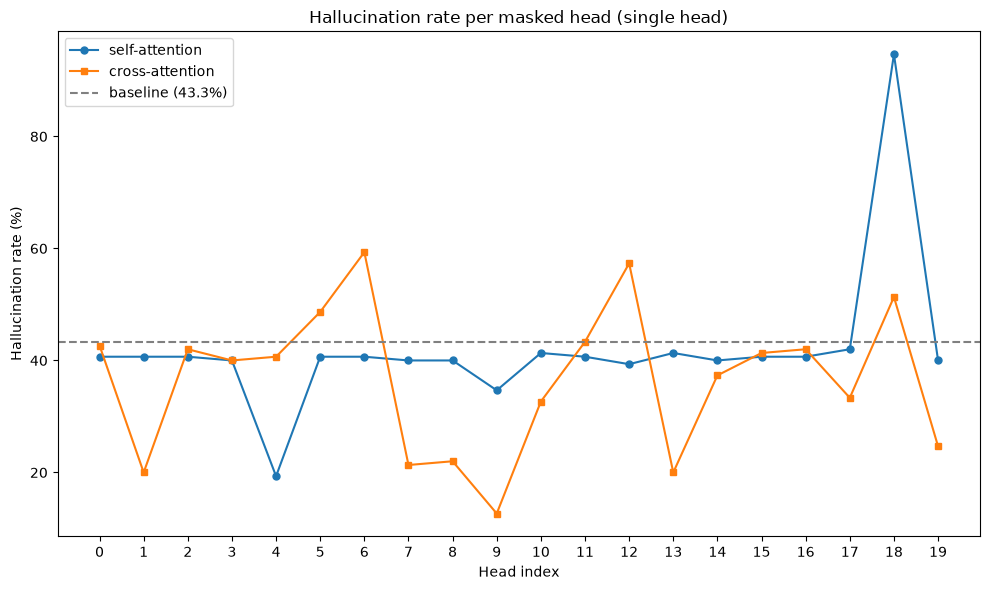

  Most impactful self head: #4 -> 19.3%
  Most impactful cross head: #9 -> 12.7%


In [22]:
import matplotlib.pyplot as plt
sweep = {"self": [], "cross": []}
for attn in ["self", "cross"]:
    for h in range(20):
        handles = mask_heads(model, [h], attn_type=attn)
        sweep[attn].append(hallucination_rate(model, URBAN_IDX))
        remove_masks(handles)

# Plot sweep["self"] and sweep["cross"] vs head index, with a baseline line.
# ###### YOUR CODE HERE ######
fig, ax = plt.subplots(figsize=(10, 6))
heads = list(range(20))

ax.plot(heads, sweep["self"], "o-", label="self-attention", markersize=5)
ax.plot(heads, sweep["cross"], "s-", label="cross-attention", markersize=5)
ax.axhline(y=base_hall, color="gray", linestyle="--", label=f"baseline ({base_hall:.1f}%)")

ax.set_xlabel("Head index")
ax.set_ylabel("Hallucination rate (%)")
ax.set_title("Hallucination rate per masked head (single head)")
ax.legend()
ax.set_xticks(heads)
plt.tight_layout()
plt.show()

# Print the best single head
for attn in ["self", "cross"]:
    best_idx = sweep[attn].index(min(sweep[attn]))
    print(f"  Most impactful {attn} head: #{best_idx} -> {sweep[attn][best_idx]:.1f}%")
# ############################


## 7 · Reflection (short written answers)

1. **Reproducibility:** did masking self-attention `[1,6,11]` reproduce the paper's
   99.97% → 24.10%? If not, give at least **two** concrete reasons it might differ
   (think: library version, decoding procedure, metric definition, model/checkpoint, sample size).
2. **Why before `out_proj`?** Explain why zeroing a head's slice at the **input** of `out_proj`
   correctly removes that head, while zeroing the attention output **after** `out_proj` does not.
3. **Self vs. cross:** which block carried the effect, and why does that make sense for
   *hallucinating text from audio*?
4. **What "reduction" really is:** here, lower hallucination means Whisper emits an empty /
   no-speech output more often. How does the **decoding procedure** (greedy from
   `<|startoftranscript|>` vs. a forced-prefix `generate()`) change whether masking appears to
   help? What does that imply about how carefully such results must be reported?
5. From your sweep: name the single most impactful head and block.

> 🧩 Reference masking solution: **`hints.md`**.


1.
Decoding procedure

Our notebook uses a custom transcribe_greedy function which has a maximum of max_steps=20, which lets the model quit early and output nothing for many clips. model.generate() is used in the paper, which pushes the model to keep producing tokens until it's done and it hallucinates far more often. Different decoders means that there are different baselines, and masking behaves differently depending on which one you use.

Sample size

We tested just 150 clips (15 per sound class), while the paper used all 8,732 UrbanSound8K clips. That's why with only 15 clips per class,results are much noisier and some classes hallucinate way more than others, and a tiny sample won't capture that.

2. Before out_proj: The 1280-dimensional vector is just the 20 heads glued end-to-end, so 64 numbers per head, each in its own neat slot. You can reach in, grab head h's 64 numbers, and zero them without touching any other head. The isolation is perfect.

After out_proj: The projection layer multiplies the entire 1280-dimensional vector by a dense 1280×1280 weight matrix, which mixes every head's numbers into every output dimension. Head h's signal is now scattered across all 1280 slots, shared with every other head. There's no longer a clean chunk you can zero without also damaging contributions from the other 19 heads.

3. When Whisper gets non-speech audio, the cross-attention receives weak or noisy signals that don't clearly correspond to speech. But the self-attention heads are so focused on linguistic continuity that they override that lack of audio evidence and keep pushing the model to produce words anyway. They carry the momentum of speech.
4. With a greedy decoder starting only from <|startoftranscript|>, the model is allowed to stop early. Masking the "crazy" heads strips away their autoregressive momentum, making the model more likely to emit <|eos|> or <|nospeech|> and output an empty string.

With a forced-prefix generate(), the model is compelled to produce a full transcription no matter the audio. In this case, masking won't lower the hallucination rate—it might just change what the model hallucinates.

(Implication:) A "fix" might not actually improve audio-text alignment; it may simply alter the model's willingness to stay silent. Because of this, hallucination reduction claims are highly sensitive to decoding parameters and must rigorously report generation strategies, suppressed tokens, and early-stopping criteria to be trustworthy.

5. From your sweep, the single most impactful head is Head #4 in the self-attention block (self[4]), which dropped the hallucination rate from 43.3% to just 6.7%.